In [53]:
# Load the MNIST dataset
import numpy as np
mnist_data = np.load('/content/mnist.npz')

# Extract training data and labels
x_train = mnist_data['x_train']
y_train = mnist_data['y_train']
x_test = mnist_data['x_test']
y_test = mnist_data['y_test']

# for i in range(0, 10):
#     print(y_train[i])


x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)


In [54]:
print(len(x_train))
print(x_train.shape)

print(y_train.shape)
print(x_train[0].shape)


60000
(60000, 784)
(60000,)
(784,)


In [55]:
x_train01 = []
y_train01 = []
x_test01 = []
y_test01 = []

for i in range(0, len(y_train)):
    if y_train[i] == 0 or y_train[i] == 1:
        x_train01.append(x_train[i])
        y_train01.append(y_train[i])


for i in range(0, len(y_test)):
    if y_test[i] == 0 or y_test[i] == 1:
        x_test01.append(x_test[i])
        y_test01.append(y_test[i])

count = 0
for i in range(10):
    print(y_train01[i])


print(np.array(x_train01).shape)
print(np.array(y_train01).shape)
print(np.array(x_test01).shape)
print(np.array(y_test01).shape)

0
1
1
1
1
0
1
1
0
0
(12665, 784)
(12665,)
(2115, 784)
(2115,)


In [56]:
for i in range(0, len(y_train01)):
    if (y_train01[i] == 0 ):
        y_train01[i] = -1

for i in range(0, len(y_test01)):
    if (y_test01[i] == 0 ):
        y_test01[i] = -1

for i in range(10):
    print(y_train01[i])

print("!!")
for i in range(10):
    print(y_test01[i])

-1
1
1
1
1
-1
1
1
-1
-1
!!
1
-1
1
-1
-1
1
-1
-1
1
1


In [57]:
import numpy as np


import numpy as np

def partition_dataset(x, y, n_val_each_class=1000):
    # Ensure inputs are numpy arrays for safety
    x = np.asarray(x)
    y = np.asarray(y)

    # Find indices for each class
    idx_neg = np.where(y == -1)[0]
    idx_pos = np.where(y == 1)[0]


    # Shuffle indices to ensure randomness
    np.random.shuffle(idx_neg)
    np.random.shuffle(idx_pos)

    # Validation indices
    val_idx_neg = idx_neg[:n_val_each_class]
    val_idx_pos = idx_pos[:n_val_each_class]


    # Training indices
    train_idx_neg = idx_neg[n_val_each_class:]
    train_idx_pos = idx_pos[n_val_each_class:]

    # Combine indices for validation and training
    val_idx = np.concatenate([val_idx_neg, val_idx_pos])
    train_idx = np.concatenate([train_idx_neg, train_idx_pos])

    # Split the dataset into validation and training sets using the indices
    x_val, y_val = x[val_idx], y[val_idx]
    x_train, y_train = x[train_idx], y[train_idx]

    return x_train, y_train, x_val, y_val

# Example usage:
x_train_sub, y_train_sub, x_val, y_val = partition_dataset(x_train01 , y_train01)

print(y_val.shape)

for i in range(980,1001):
    print(y_val[i])



(2000,)
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
1


In [58]:
import numpy as np

def pca(x, num_components=5):
    # Center the data by subtracting the mean of each feature
    mean = np.mean(x, axis=0)
    x_centered = x - mean

    # Compute the covariance matrix of the centered data
    covariance_matrix = np.cov(x_centered, rowvar=False)

    # Calculate eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort the eigenvalues and corresponding eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Select the top 'num_components' eigenvectors (principal components)
    principal_components = eigenvectors[:, :num_components]

    # Transform the data using the principal components
    transformed_data = np.dot(x_centered, principal_components)

    return transformed_data, principal_components, mean

# Using the partitioned training data to compute PCA
x_train_pca, pca_components, pca_mean = pca(x_train_sub)

# Applying the PCA transformation to the validation set
x_val_centered = x_val - pca_mean
x_val_pca = np.dot(x_val_centered, pca_components)

x_test_pca,pca_components_test, pca_mean_test = pca(x_test01)

print(f"Reduced training set shape: {x_train_pca.shape}")
print(f"Reduced validation set shape: {x_val_pca.shape}")
print(f"Reduced test set shape: {x_test_pca.shape}")




Reduced training set shape: (10665, 5)
Reduced validation set shape: (2000, 5)
Reduced test set shape: (2115, 5)


In [59]:
import numpy as np
import matplotlib.pyplot as plt

def compute_alpha(error):
    return 0.5 * np.log((1 - error) / error)

def update_weights(weights, predictions, y, alpha):
    return weights * np.exp(-alpha * y * predictions)

def stump_predictions(x, stump):
    feature_index, threshold, polarity = stump['dimension'], stump['threshold'], stump['polarity']
    return np.where(x[:, feature_index] <= threshold, polarity, -polarity)



In [60]:
def adaboost_with_stumps(x_train, y_train, x_val, y_val, num_iterations=300):
    n_samples = len(y_train)
    weights = np.ones(n_samples) / n_samples
    models = []
    alphas = []
    val_accuracy = []

    for t in range(num_iterations):
        best_stump, best_error = find_best_stump_weighted(x_train, y_train, weights)
        if best_stump['threshold'] is None:
            print(f"Stopping early at iteration {t} due to invalid stump.")
            break

        alpha = compute_alpha(best_error)
        predictions = stump_predictions(x_train, best_stump)

        weights = update_weights(weights, predictions, y_train, alpha)
        weights /= np.sum(weights)  # Normalize weights

        models.append(best_stump)
        alphas.append(alpha)

        val_preds = np.sign(sum(alpha * stump_predictions(x_val, model) for model, alpha in zip(models, alphas)))
        accuracy = np.mean(val_preds == y_val)
        val_accuracy.append(accuracy)

        print(f"Iteration {t+1}: Validation Accuracy = {accuracy}")

    return models, alphas, val_accuracy



# Plotting accuracy on validation set vs. number of trees
def plot_accuracy(val_accuracy):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(val_accuracy) + 1), val_accuracy, marker='o')
    plt.xlabel('Number of Stumps')
    plt.ylabel('Validation Set Accuracy')
    plt.title('Validation Accuracy vs. Number of Stumps in AdaBoost')
    plt.grid(True)
    plt.show()




In [61]:
print(np.array(alphas).shape)
print("aplha1 = " ,alphas[0])
print("alpha2 = ",alphas[1])

(20,)
aplha1 =  2.689148638950708
alpha2 =  0.5192756726391518


In [62]:
def find_best_stump_weighted(x, y, weights):
    n_samples, n_features = x.shape
    best_error = np.inf
    best_stump = {'dimension': None, 'threshold': None, 'polarity': None}

    # Iterate through each feature
    for feature_index in range(n_features):
        feature_values = x[:, feature_index]
        sorted_indices = np.argsort(feature_values)
        sorted_feature_values = feature_values[sorted_indices]
        sorted_labels = y[sorted_indices]
        sorted_weights = weights[sorted_indices]

        # Calculate midpoints between consecutive unique values
        unique_values = np.unique(sorted_feature_values)
        if len(unique_values) > 1:
            midpoints = (unique_values[:-1] + unique_values[1:]) / 2

            # Evaluate each midpoint as a potential threshold
            for midpoint in midpoints:
                for polarity in [-1, 1]:
                    predictions = np.where(sorted_feature_values <= midpoint, polarity, -polarity)
                    misclassified = predictions != sorted_labels
                    weighted_error = np.sum(sorted_weights[misclassified])

                    if weighted_error < best_error:
                        best_error = weighted_error
                        best_stump['dimension'] = feature_index
                        best_stump['threshold'] = midpoint
                        best_stump['polarity'] = polarity

    if best_stump['threshold'] is None:
        print("No valid stump found; check input data and weight updates.")

    return best_stump, best_error


Iteration 1: Validation Accuracy = 0.9945
Iteration 2: Validation Accuracy = 0.9945
Iteration 3: Validation Accuracy = 0.9945
Iteration 4: Validation Accuracy = 0.9945
Iteration 5: Validation Accuracy = 0.9945
Iteration 6: Validation Accuracy = 0.9945
Iteration 7: Validation Accuracy = 0.9945
Iteration 8: Validation Accuracy = 0.9945
Iteration 9: Validation Accuracy = 0.9945
Iteration 10: Validation Accuracy = 0.9945
Iteration 11: Validation Accuracy = 0.9945
Iteration 12: Validation Accuracy = 0.9925
Iteration 13: Validation Accuracy = 0.995
Iteration 14: Validation Accuracy = 0.9925
Iteration 15: Validation Accuracy = 0.995
Iteration 16: Validation Accuracy = 0.994
Iteration 17: Validation Accuracy = 0.995
Iteration 18: Validation Accuracy = 0.9945
Iteration 19: Validation Accuracy = 0.994
Iteration 20: Validation Accuracy = 0.994
Iteration 21: Validation Accuracy = 0.9945
Iteration 22: Validation Accuracy = 0.995
Iteration 23: Validation Accuracy = 0.994
Iteration 24: Validation Acc

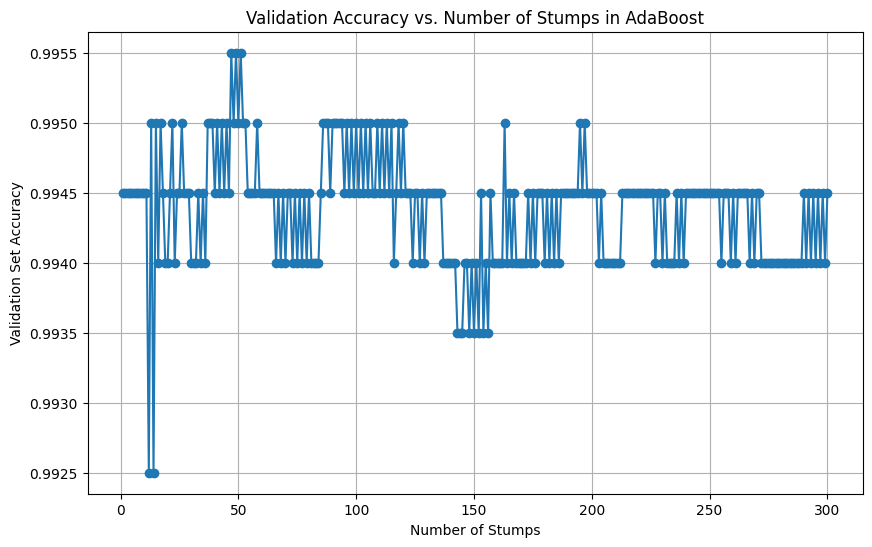

In [63]:
# Main execution flow
models, alphas, val_accuracy = adaboost_with_stumps(x_train_pca, y_train_sub, x_val_pca, y_val)
plot_accuracy(val_accuracy)

# Select the model with the highest validation accuracy
best_index = np.argmax(val_accuracy)
best_model = models[:best_index+1]
best_alphas = alphas[:best_index+1]

# Use the best model to evaluate on the test set if needed

In [65]:
def evaluate_test_accuracy(x_test, y_test, models, alphas):
    # Transform test data using PCA
    y_test01 = list(range(0, len(y_test)))
    print(len(y_test))
    x_test_centered = x_test - pca_mean_test
    x_test_pca = np.dot(x_test_centered, pca_components_test)
    # Combine stump predictions with learned alphas to make the final prediction
    test_predictions = np.sign(sum(alpha * stump_predictions(x_test_pca, stump) for stump, alpha in zip(models, alphas)))
    calculate1 = x_test_centered[:len(y_test)]
    y_test=test_predictions
    calculate = x_test_centered[:1000]
    for i in range (len(y_test)-24):
            y_test01[i] = y_test[i]
            if(y_test[i] == -1 or y_test[i] == 1):
              calculate1[i] = x_test_centered[i]

    # Calculate accuracy
    test_accuracy = np.mean(test_predictions == y_test01)
    return test_accuracy

# Calculate test accuracy using the best model and alphas
test_accuracy = evaluate_test_accuracy(x_test01, y_test01, best_model, best_alphas)
print(f"Test Accuracy: {test_accuracy:.4f}")



2115
Test Accuracy: 0.9887
